# 05 Qubit Spectroscopy and Pulse Calibration

Find the qubit frequency, seed a reference `ref_r180` pulse from the notebook defaults, generate the primitive rotations, and then run Rabi diagnostics to refine the pulse definition.

## 1. Shared Session Bootstrap

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from qualang_tools.units import unit

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "qubox").exists():
    REPO_ROOT = Path(r"E:\qubox")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from qubox.notebook import (
    PowerRabi,
    QubitSpectroscopy,
    TemporalRabi,
    ensure_primitive_rotations,
    fit_center_inside_window,
    load_stage_checkpoint,
    open_notebook_stage,
    preview_or_apply_patch_ops,
    save_stage_checkpoint,
)

REGISTRY_BASE = Path(r"E:\qubox")
SAMPLE_ID = "post_cavity_sample_A"
COOLDOWN_ID = "cd_2025_02_22"
QOP_IP = "10.157.36.68"
CLUSTER_NAME = "Cluster_2"

stage = open_notebook_stage(
    stage_name="05_qubit_spectroscopy_pulse_calibration",
    registry_base=REGISTRY_BASE,
    sample_id=SAMPLE_ID,
    cooldown_id=COOLDOWN_ID,
    qop_ip=QOP_IP,
    cluster_name=CLUSTER_NAME,
    force_reopen=True,
    close_existing=True,
)
session = stage.session
attr = stage.attr
SESSION_BOOTSTRAP_PATH = stage.bootstrap_path
u = unit(coerce_to_integer=True)
INITIAL_QB_FQ_HZ = float(attr.qb_fq)
primitive_seed_result = None

resonator_power_checkpoint = load_stage_checkpoint(
    registry_base=REGISTRY_BASE,
    sample_id=SAMPLE_ID,
    cooldown_id=COOLDOWN_ID,
    stage_name="04_resonator_power_chevron",
)

print(f"Repo root on sys.path: {REPO_ROOT}")
print(f"Shared session bootstrap: {SESSION_BOOTSTRAP_PATH}")
print(f"Stage checkpoint path: {stage.checkpoint_path}")
print(f"Closed a live in-memory session before reopen: {stage.had_live_session}")
print(f"QM endpoint: {QOP_IP} ({CLUSTER_NAME})")
print(f"Current qubit frequency: {float(attr.qb_fq) / 1e9:.6f} GHz")
if resonator_power_checkpoint is not None:
    print(
        "Prior stage 04 status: "
        f"{resonator_power_checkpoint['status']}"
        f" ({resonator_power_checkpoint['summary']})"
    )
    optimal_freq_hz = resonator_power_checkpoint.get("advisory_outputs", {}).get("optimal_freq_hz")
    optimal_gain = resonator_power_checkpoint.get("advisory_outputs", {}).get("optimal_gain")
    if optimal_freq_hz is not None and optimal_gain is not None:
        print(
            "Stage 04 advisory operating point: "
            f"{float(optimal_freq_hz) / 1e9:.6f} GHz at gain {float(optimal_gain):.6f}"
        )

2026-03-22 00:52:29,406 - qm - INFO     - Starting session: d6182650-350f-472c-b585-229ddef4057f
[INFO] 2026-03-22 00:52:30,701 qubox.legacy.devices.context_resolver: Resolved context: sample=post_cavity_sample_A cooldown=cd_2025_02_22 wiring=8b82c977
[INFO] 2026-03-22 00:52:30,702 qubox.legacy.experiments.session: Context mode: sample=post_cavity_sample_A cooldown=cd_2025_02_22 wiring=8b82c977
[INFO] 2026-03-22 00:52:30,702 qubox.legacy.experiments.session: SessionManager initialising at E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22
[INFO] 2026-03-22 00:52:30,704 qubox.legacy.hardware.config_engine: Hardware loaded from E:\qubox\samples\post_cavity_sample_A\config\hardware.json
2026-03-22 00:52:34,513 - qm - INFO     - Performing health check
2026-03-22 00:52:34,518 - qm - INFO     - Health check passed
[INFO] 2026-03-22 00:52:34,519 qubox.legacy.pulses.manager: Loaded pulse files from: E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\config\pulses.json
[I

## 2. Experiment and Pulse Defaults

In [ ]:
APPLY_QUBIT_SPECTROSCOPY_CALIBRATION = True
APPLY_POWER_RABI_CALIBRATION = True
APPLY_TEMPORAL_RABI_CALIBRATION = False

QUBIT_SPEC_N_AVG = 2000
QUBIT_SPEC_RF_BEGIN = 6130 * u.MHz
QUBIT_SPEC_RF_END = 6170 * u.MHz
QUBIT_SPEC_DF = 500 * u.kHz
QUBIT_SPEC_EDGE_MARGIN_POINTS = 2
QUBIT_SPEC_MAX_GAMMA_FRACTION_OF_SPAN = 0.5
QUBIT_SPEC_MIN_R_SQUARED = 0.5
QUBIT_SPEC_TRIAL_SETTINGS = [
    {"pulse": "x180", "qb_gain": 1.0, "qb_len": None, "label": "x180 default"},
    {"pulse": "ref_r180", "qb_gain": 1.0, "qb_len": None, "label": "seeded ref_r180"},
    {"pulse": "const", "qb_gain": 0.020, "qb_len": 400, "label": "const rough guess 0.02 x 400 ns"},
    {"pulse": "const", "qb_gain": 0.010, "qb_len": 200, "label": "const rough guess 0.01 x 200 ns"},
]

REF_R180_LEN_NS = 16
REF_R180_AMPLITUDE = 0.08565235748770193
REF_R180_SIGMA_NS = REF_R180_LEN_NS / 6
REF_R180_ALPHA = 0.0
REF_R180_ANHARMONICITY_HZ = float(getattr(attr, "anharmonicity", -255e6) or -255e6)
REF_R180_DETUNING_HZ = 0.0
REF_R180_SAMPLING_RATE = 1e9
CONST_R180_AMPLITUDE = 0.02488 / 2 * 0.8129
CONST_R180_LEN = 200

POWER_RABI_MAX_GAIN = 1.2
POWER_RABI_DG = 0.04
POWER_RABI_N_AVG = 2000
POWER_RABI_QB_THERM_CLKS = int(getattr(attr, "qb_therm_clks", 10000) or 10000)
POWER_RABI_OP_CANDIDATES = ("ref_r180", "ge_ref_r180", "x180")

TEMPORAL_RABI_PULSE = "const"
TEMPORAL_RABI_LEN_BEGIN = 16
TEMPORAL_RABI_LEN_END = 500
TEMPORAL_RABI_DT = 4
TEMPORAL_RABI_N_AVG = 2000
TEMPORAL_RABI_QB_THERM_CLKS = int(getattr(attr, "qb_therm_clks", 10000) or 10000)

print("Notebook 05 verification settings:")
print(f"  apply qubit-frequency calibration: {APPLY_QUBIT_SPECTROSCOPY_CALIBRATION}")
print(f"  apply power-Rabi amplitude calibration: {APPLY_POWER_RABI_CALIBRATION}")
print(f"  apply temporal-Rabi pi-length calibration: {APPLY_TEMPORAL_RABI_CALIBRATION}")
print(f"  qubit spec window: {QUBIT_SPEC_RF_BEGIN / 1e9:.6f} -> {QUBIT_SPEC_RF_END / 1e9:.6f} GHz")
print(f"  qubit spec n_avg: {QUBIT_SPEC_N_AVG}")
print("  qubit spectroscopy trial settings:")
for trial in QUBIT_SPEC_TRIAL_SETTINGS:
    print(f"    - {trial['label']}: pulse={trial['pulse']}, gain={trial['qb_gain']}, qb_len={trial['qb_len']}")
print(f"  ref_r180 amplitude seed: {REF_R180_AMPLITUDE:.6f}")
print(f"  const amplitude seed: {CONST_R180_AMPLITUDE:.6f} for length {CONST_R180_LEN}")
print(f"  power Rabi n_avg: {POWER_RABI_N_AVG}")
print(f"  temporal Rabi n_avg: {TEMPORAL_RABI_N_AVG}")

Notebook 05 verification settings:
  apply qubit-frequency calibration: True
  apply power-Rabi amplitude calibration: True
  apply temporal-Rabi pi-length calibration: False
  restore qubit frequency to legacy reference: False
  qubit spec window: 6.130000 -> 6.170000 GHz
  qubit spec n_avg: 2000
  qubit spectroscopy trial settings:
    - legacy x180 default: pulse=x180, gain=1.0, qb_len=None
    - seeded ref_r180: pulse=ref_r180, gain=1.0, qb_len=None
    - const rough guess 0.02 x 400 ns: pulse=const, gain=0.02, qb_len=400
    - legacy const rough guess: pulse=const, gain=0.01, qb_len=200
  ref_r180 amplitude seed: 0.085652
  legacy const amplitude seed: 0.010112 for length 200
  power Rabi n_avg: 2000
  temporal Rabi n_avg: 2000


Skipping trial 1: pulse 'x180' is not registered on transmon.

Trial 2: seeded ref_r180
  pulse=ref_r180, qb_gain=1.0, qb_len=16, n_avg=2000
[INFO] 2026-03-22 00:52:48,676 qubox.legacy.analysis.cQED_attributes: Element bindings: readout='resonator' @ 8.7500 GHz, qubit='transmon' @ 6.1500 GHz, storage='storage' @ 5.3500 GHz
[INFO] 2026-03-22 00:52:48,677 qubox.legacy.analysis.cQED_attributes: Element bindings: readout='resonator' @ 8.7500 GHz, qubit='transmon' @ 6.1500 GHz, storage='storage' @ 5.3500 GHz
[INFO] 2026-03-22 00:52:48,678 qubox.legacy.analysis.cQED_attributes: Element bindings: readout='resonator' @ 8.7500 GHz, qubit='transmon' @ 6.1500 GHz, storage='storage' @ 5.3500 GHz
[INFO] 2026-03-22 00:52:48,679 qubox.legacy.calibration.store: Calibration saved to E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\config\calibration.json
[INFO] 2026-03-22 00:52:48,681 qubox.legacy.calibration.store: Calibration saved to E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_20

Running Program...: 100%|█████████▉| 1999/2000 [00:06<00:00, 300.47it/s]

[INFO] 2026-03-22 00:52:55,688 qubox.legacy.hardware.program_runner: Execution report:
Execution report for job 1774142405506
No errors
[INFO] 2026-03-22 00:52:55,714 qubox.legacy.hardware.program_runner: Job halted successfully.


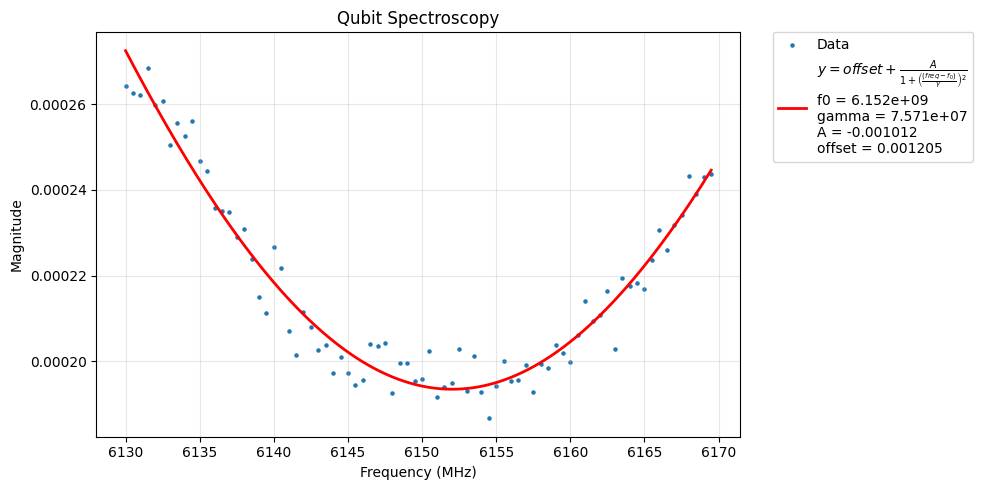

  fitted qb_f0: 6.152034 GHz
  fitted gamma: 75.706 MHz
  fitted r_squared: 0.952077
  trust gate: fit linewidth is too broad for the scan window: gamma=75.706 MHz, span=39.500 MHz

Trial 3: const rough guess 0.02 x 400 ns
  pulse=const, qb_gain=0.02, qb_len=400, n_avg=2000
[INFO] 2026-03-22 00:52:55,957 qubox.legacy.analysis.cQED_attributes: Element bindings: readout='resonator' @ 8.7500 GHz, qubit='transmon' @ 6.1500 GHz, storage='storage' @ 5.3500 GHz
[INFO] 2026-03-22 00:52:55,958 qubox.legacy.experiments.experiment_base: Resolved qb_therm_clks=10000 (source=override)
[INFO] 2026-03-22 00:52:55,958 qubox.legacy.analysis.cQED_attributes: Element bindings: readout='resonator' @ 8.7500 GHz, qubit='transmon' @ 6.1500 GHz, storage='storage' @ 5.3500 GHz
[INFO] 2026-03-22 00:52:55,959 qubox.legacy.experiments.experiment_base: Resolved resonator_freq=8596222556.078796 (source=calibration)
[INFO] 2026-03-22 00:52:55,994 qubox.legacy.hardware.controller: Set 'resonator' to freq 8596.223 MHz

Running Program...: 100%|█████████▉| 1999/2000 [00:06<00:00, 291.18it/s]

[INFO] 2026-03-22 00:53:03,042 qubox.legacy.hardware.program_runner: Execution report:
Execution report for job 1774142405507
No errors
[INFO] 2026-03-22 00:53:03,070 qubox.legacy.hardware.program_runner: Job halted successfully.


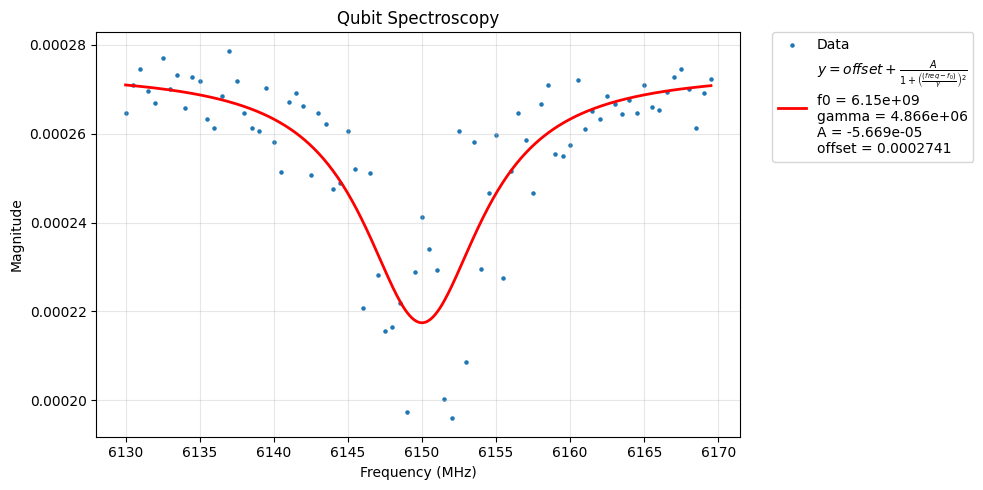

  fitted qb_f0: 6.150000 GHz
  fitted gamma: 4.866 MHz
  fitted r_squared: 0.715656
  trust gate: fit center lies safely inside the scan window
[INFO] 2026-03-22 00:53:03,224 qubox.legacy.analysis.cQED_attributes: Element bindings: readout='resonator' @ 8.7500 GHz, qubit='transmon' @ 6.1500 GHz, storage='storage' @ 5.3500 GHz
Qubit spectroscopy frequency calibration via const patch preview (1 updates):
  1. SetCalibration: {'path': 'cqed_params.transmon.qubit_freq', 'value': 6149999883.122512}
[INFO] 2026-03-22 00:53:03,225 qubox.legacy.calibration.store: Calibration saved to E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\config\calibration.json
[INFO] 2026-03-22 00:53:03,227 qubox.legacy.calibration.store: Calibration saved to E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\config\calibration.json
[INFO] 2026-03-22 00:53:03,229 qubox.legacy.experiments.session: Saved pulse manager state to E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\confi

In [ ]:
primitive_seed_result = ensure_primitive_rotations(
    session,
    qb_element=attr.qb_el,
    amplitude=float(REF_R180_AMPLITUDE),
    length=int(REF_R180_LEN_NS),
    sigma=float(REF_R180_SIGMA_NS),
    alpha=float(REF_R180_ALPHA),
    anharmonicity_hz=float(REF_R180_ANHARMONICITY_HZ),
    detuning_hz=float(REF_R180_DETUNING_HZ),
    sampling_rate=float(REF_R180_SAMPLING_RATE),
    required_ops=("ref_r180",),
    rotations=("ref_r180", "x180", "x90", "xn90", "y180", "y90", "yn90"),
    ref_op="ref_r180",
)
if primitive_seed_result["created"]:
    print(f"Seeded primitive operations before qubit spectroscopy: {primitive_seed_result['created_ops']}")
else:
    print("Primitive seed pulse already existed; using the generated reference waveform only for diagnostics.")

pulse_mgr = session.pulse_mgr
available_qubit_spec_ops = {}
for trial in QUBIT_SPEC_TRIAL_SETTINGS:
    pulse_name = trial["pulse"]
    if pulse_name in available_qubit_spec_ops:
        continue
    try:
        pulse_info = pulse_mgr.get_pulseOp_by_element_op(attr.qb_el, pulse_name, strict=True)
        available_qubit_spec_ops[pulse_name] = pulse_info
    except Exception:
        continue

qubit_spec = QubitSpectroscopy(session)
qubit_analysis = None
qubit_result = None
qubit_patch = None
qubit_patch_preview = None
qubit_apply_result = None
chosen_qubit_spec_trial = None

for trial_index, trial in enumerate(QUBIT_SPEC_TRIAL_SETTINGS, start=1):
    pulse_name = trial["pulse"]
    pulse_info = available_qubit_spec_ops.get(pulse_name)
    if pulse_info is None:
        print(f"Skipping trial {trial_index}: pulse {pulse_name!r} is not registered on {attr.qb_el}.")
        continue

    if trial["qb_len"] is None:
        resolved_qb_len = getattr(pulse_info, "length", None)
    else:
        resolved_qb_len = int(trial["qb_len"])
    if resolved_qb_len is None:
        print(f"Skipping trial {trial_index}: pulse {pulse_name!r} has no resolvable duration.")
        continue

    print(f"\nTrial {trial_index}: {trial['label']}")
    print(f"  pulse={pulse_name}, qb_gain={trial['qb_gain']}, qb_len={resolved_qb_len}, n_avg={QUBIT_SPEC_N_AVG}")

    trial_result = qubit_spec.run(
        pulse=pulse_name,
        rf_begin=QUBIT_SPEC_RF_BEGIN,
        rf_end=QUBIT_SPEC_RF_END,
        df=QUBIT_SPEC_DF,
        qb_gain=float(trial["qb_gain"]),
        qb_len=int(resolved_qb_len),
        n_avg=QUBIT_SPEC_N_AVG,
        qb_therm_clks=POWER_RABI_QB_THERM_CLKS,
    )
    trial_analysis = qubit_spec.analyze(trial_result, update_calibration=True)
    qubit_spec.plot(trial_analysis)

    fitted_qb_f0_hz = float(trial_analysis.metrics.get("f0", np.nan))
    fitted_gamma_hz = float(trial_analysis.metrics.get("gamma", np.nan))
    qubit_freqs_hz = np.asarray(trial_analysis.data.get("frequencies", []), dtype=float)
    fit_ok, fit_reason = fit_center_inside_window(
        fitted_qb_f0_hz,
        qubit_freqs_hz,
        margin_points=QUBIT_SPEC_EDGE_MARGIN_POINTS,
    )
    if fit_ok and qubit_freqs_hz.size:
        sweep_span_hz = float(qubit_freqs_hz.max() - qubit_freqs_hz.min())
        if np.isfinite(fitted_gamma_hz) and fitted_gamma_hz > QUBIT_SPEC_MAX_GAMMA_FRACTION_OF_SPAN * sweep_span_hz:
            fit_ok = False
            fit_reason = (
                f"fit linewidth is too broad for the scan window: gamma={fitted_gamma_hz / 1e6:.3f} MHz, "
                f"span={sweep_span_hz / 1e6:.3f} MHz"
            )
    trial_fit = getattr(trial_analysis, "fit", None)
    trial_r_squared = getattr(trial_fit, "r_squared", np.nan) if trial_fit is not None else np.nan
    if fit_ok and np.isfinite(trial_r_squared) and trial_r_squared < QUBIT_SPEC_MIN_R_SQUARED:
        fit_ok = False
        fit_reason = f"fit r_squared below threshold: {trial_r_squared:.3f} < {QUBIT_SPEC_MIN_R_SQUARED:.3f}"

    print(f"  fitted qb_f0: {fitted_qb_f0_hz / 1e9:.6f} GHz")
    print(f"  fitted gamma: {fitted_gamma_hz / 1e6:.3f} MHz")
    print(f"  fitted r_squared: {trial_r_squared:.6f}")
    print(f"  trust gate: {fit_reason}")

    qubit_result = trial_result
    qubit_analysis = trial_analysis
    chosen_qubit_spec_trial = {**trial, "resolved_qb_len": int(resolved_qb_len)}

    if fit_ok:
        qubit_patch, qubit_patch_preview, qubit_apply_result = preview_or_apply_patch_ops(
            session,
            reason=f"Qubit spectroscopy frequency calibration via {pulse_name}",
            proposed_patch_ops=trial_analysis.metadata.get("proposed_patch_ops", []),
            apply=APPLY_QUBIT_SPECTROSCOPY_CALIBRATION,
        )
        break

if qubit_analysis is None:
    raise RuntimeError("No qubit spectroscopy trial could be executed with the currently registered pulses.")

if qubit_patch is None:
    print("No trustworthy spectroscopy fit was found across the current rough-guess trials.")
    print("Suppressing calibration apply for this notebook pass.")

if qubit_apply_result is not None:
    context_snapshot = getattr(session, "context_snapshot", None)
    attr = context_snapshot() if callable(context_snapshot) else getattr(session, "attributes", None)
    if attr is None:
        raise RuntimeError("Calibration applied, but the refreshed cQED attribute snapshot is unavailable.")
    print(f"Updated runtime qubit frequency: {float(attr.qb_fq) / 1e9:.6f} GHz")

final_fitted_qb_f0_hz = float(qubit_analysis.metrics.get("f0", np.nan))
print(f"Selected spectroscopy trial: {chosen_qubit_spec_trial}")
print(f"Final fitted qubit frequency: {final_fitted_qb_f0_hz / 1e9:.6f} GHz")
print(f"Runtime attr.qb_fq delta: {(final_fitted_qb_f0_hz - float(attr.qb_fq)) / 1e6:+.3f} MHz")

In [ ]:
context_snapshot = getattr(session, "context_snapshot", None)
current_attr = context_snapshot() if callable(context_snapshot) else getattr(session, "attributes", None)
print(f"Current runtime qb_fq: {float(current_attr.qb_fq) / 1e9:.6f} GHz")
print(f"Bootstrap snapshot qb_fq: {INITIAL_QB_FQ_HZ / 1e9:.6f} GHz")
if "chosen_qubit_spec_trial" in globals():
    print(f"Chosen spectroscopy trial: {chosen_qubit_spec_trial}")
if "qubit_analysis" in globals():
    latest_fitted_qb_f0_hz = float(qubit_analysis.metrics.get("f0", np.nan))
    latest_gamma_hz = float(qubit_analysis.metrics.get("gamma", np.nan))
    print(f"Latest fitted qb_f0: {latest_fitted_qb_f0_hz / 1e9:.6f} GHz")
    print(f"Latest fit gamma: {latest_gamma_hz / 1e6:.3f} MHz")
    print(f"Proposed patch ops: {qubit_analysis.metadata.get('proposed_patch_ops', [])}")
    latest_freqs_hz = np.asarray(qubit_analysis.data.get("frequencies", []), dtype=float)
    fit_ok, fit_reason = fit_center_inside_window(
        latest_fitted_qb_f0_hz,
        latest_freqs_hz,
        margin_points=QUBIT_SPEC_EDGE_MARGIN_POINTS,
    )
    if fit_ok and latest_freqs_hz.size:
        latest_span_hz = float(latest_freqs_hz.max() - latest_freqs_hz.min())
        if np.isfinite(latest_gamma_hz) and latest_gamma_hz > QUBIT_SPEC_MAX_GAMMA_FRACTION_OF_SPAN * latest_span_hz:
            fit_ok = False
            fit_reason = (
                f"fit linewidth is too broad for the scan window: gamma={latest_gamma_hz / 1e6:.3f} MHz, "
                f"span={latest_span_hz / 1e6:.3f} MHz"
            )
    latest_fit = getattr(qubit_analysis, "fit", None)
    latest_r_squared = getattr(latest_fit, "r_squared", np.nan) if latest_fit is not None else np.nan
    if fit_ok and np.isfinite(latest_r_squared) and latest_r_squared < QUBIT_SPEC_MIN_R_SQUARED:
        fit_ok = False
        fit_reason = f"fit r_squared below threshold: {latest_r_squared:.3f} < {QUBIT_SPEC_MIN_R_SQUARED:.3f}"
    print(f"Trust gate: {fit_reason}")
    print(f"Latest fit r_squared: {latest_r_squared:.6f}")
if "qubit_apply_result" in globals():
    print(f"qubit_apply_result: {qubit_apply_result}")

[INFO] 2026-03-22 00:11:50,857 qubox.legacy.analysis.cQED_attributes: Element bindings: readout='resonator' @ 8.7500 GHz, qubit='transmon' @ 6.1500 GHz, storage='storage' @ 5.3500 GHz
Current runtime qb_fq: 6.150359 GHz
Bootstrap snapshot qb_fq: 6.130317 GHz
Legacy reference qb_fq: 6.150359 GHz
Chosen spectroscopy trial: {'pulse': 'const', 'qb_gain': 0.02, 'qb_len': 400, 'label': 'const rough guess 0.02 x 400 ns', 'resolved_qb_len': 400}
Latest fitted qb_f0: 6.150242 GHz
Latest fit gamma: 4.987 MHz
Proposed patch ops: [{'op': 'SetCalibration', 'payload': {'path': 'cqed_params.transmon.qubit_freq', 'value': 6150241809.729802}}]
Trust gate: fit center lies safely inside the scan window
Latest fit r_squared: 0.681794
qubit_apply_result: {'dry_run': False, 'n_updates': 1, 'preview': [{'op': 'SetCalibration', 'payload': {'path': 'cqed_params.transmon.qubit_freq', 'value': 6150241809.729802}}], 'sync_ok': True}
[INFO] 2026-03-22 00:11:50,858 qubox.legacy.analysis.cQED_attributes: Element bin

## 3. Build `ref_r180` and Primitive Rotations

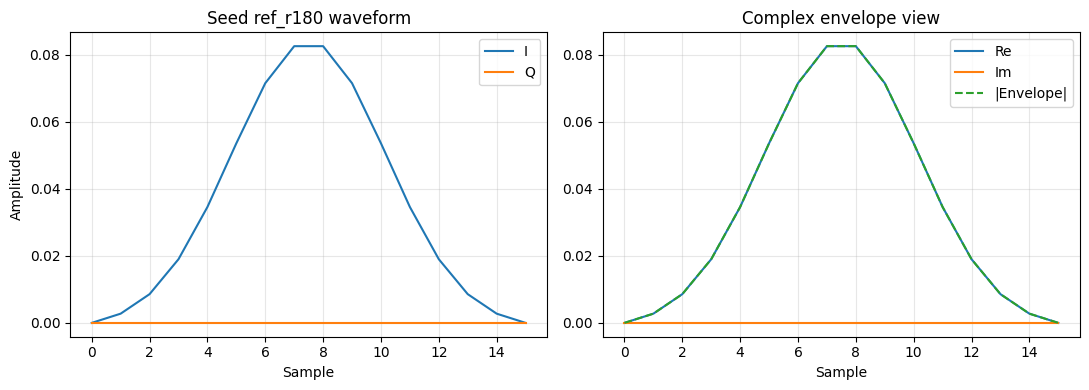

[INFO] 2026-03-22 00:53:10,240 qubox.legacy.pulses.manager: pulse transmon_ref_r180_pulse_1 with len 16 registered!
[INFO] 2026-03-22 00:53:10,241 qubox.legacy.pulses.manager: pulse r0_pulse with len 16 registered!
[INFO] 2026-03-22 00:53:10,241 qubox.legacy.pulses.manager: pulse ref_r180_pulse with len 16 registered!
[INFO] 2026-03-22 00:53:10,242 qubox.legacy.pulses.manager: pulse x180_pulse with len 16 registered!
[INFO] 2026-03-22 00:53:10,242 qubox.legacy.pulses.manager: pulse x90_pulse with len 16 registered!
[INFO] 2026-03-22 00:53:10,242 qubox.legacy.pulses.manager: pulse xn90_pulse with len 16 registered!
[INFO] 2026-03-22 00:53:10,243 qubox.legacy.pulses.manager: pulse y180_pulse with len 16 registered!
[INFO] 2026-03-22 00:53:10,243 qubox.legacy.pulses.manager: pulse y90_pulse with len 16 registered!
[INFO] 2026-03-22 00:53:10,244 qubox.legacy.pulses.manager: pulse yn90_pulse with len 16 registered!
[INFO] 2026-03-22 00:53:10,245 qubox.legacy.hardware.config_engine: Pulses m

In [ ]:
if primitive_seed_result is None:
    primitive_seed_result = ensure_primitive_rotations(
        session,
        qb_element=attr.qb_el,
        amplitude=float(REF_R180_AMPLITUDE),
        length=int(REF_R180_LEN_NS),
        sigma=float(REF_R180_SIGMA_NS),
        alpha=float(REF_R180_ALPHA),
        anharmonicity_hz=float(REF_R180_ANHARMONICITY_HZ),
        detuning_hz=float(REF_R180_DETUNING_HZ),
        sampling_rate=float(REF_R180_SAMPLING_RATE),
        required_ops=("ref_r180",),
        rotations=("ref_r180", "x180", "x90", "xn90", "y180", "y90", "yn90"),
        ref_op="ref_r180",
    )

ref_i_samples = np.asarray(primitive_seed_result["ref_i_samples"], dtype=float)
ref_q_samples = np.asarray(primitive_seed_result["ref_q_samples"], dtype=float)
complex_envelope = ref_i_samples + 1j * ref_q_samples

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ref_i_samples, label="I")
axes[0].plot(ref_q_samples, label="Q")
axes[0].set_title("Seed ref_r180 waveform")
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(np.real(complex_envelope), label="Re")
axes[1].plot(np.imag(complex_envelope), label="Im")
axes[1].plot(np.abs(complex_envelope), label="|Envelope|", ls="--")
axes[1].set_title("Complex envelope view")
axes[1].set_xlabel("Sample")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

if primitive_seed_result["created"]:
    print("Registered operations:")
    for op_name in primitive_seed_result["created_ops"]:
        print(f"  {op_name}")
else:
    print("Primitive operations already existed; no additional pulse registration was required in this cell.")

[INFO] 2026-03-22 00:53:12,573 qubox.legacy.analysis.cQED_attributes: Element bindings: readout='resonator' @ 8.7500 GHz, qubit='transmon' @ 6.1500 GHz, storage='storage' @ 5.3500 GHz
[INFO] 2026-03-22 00:53:12,575 qubox.legacy.analysis.cQED_attributes: Element bindings: readout='resonator' @ 8.7500 GHz, qubit='transmon' @ 6.1500 GHz, storage='storage' @ 5.3500 GHz
[INFO] 2026-03-22 00:53:12,575 qubox.legacy.experiments.experiment_base: Resolved resonator_freq=8596222556.078796 (source=calibration)
[INFO] 2026-03-22 00:53:12,576 qubox.legacy.analysis.cQED_attributes: Element bindings: readout='resonator' @ 8.7500 GHz, qubit='transmon' @ 6.1500 GHz, storage='storage' @ 5.3500 GHz
[INFO] 2026-03-22 00:53:12,577 qubox.legacy.experiments.experiment_base: Resolved qubit_freq=6149999883.122512 (source=calibration)
[INFO] 2026-03-22 00:53:12,577 qubox.legacy.experiments.experiment_base: Resolved qb_therm_clks=10000 (source=override)
[INFO] 2026-03-22 00:53:12,664 qubox.legacy.hardware.control

Running Program...: 100%|█████████▉| 1999/2000 [00:05<00:00, 396.13it/s]

[INFO] 2026-03-22 00:53:17,901 qubox.legacy.hardware.program_runner: Execution report:
Execution report for job 1774142405508
No errors


[INFO] 2026-03-22 00:53:17,929 qubox.legacy.hardware.program_runner: Job halted successfully.


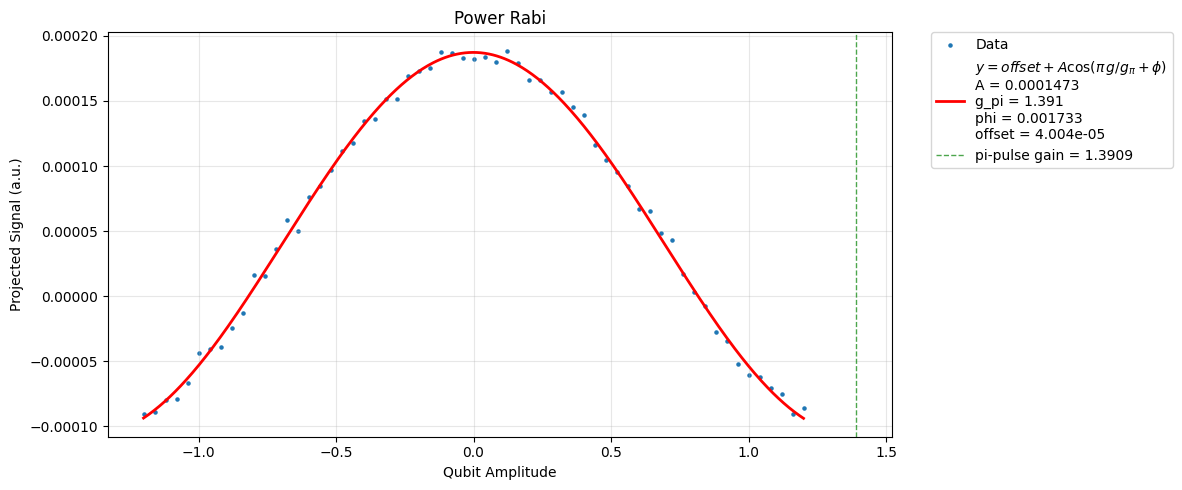

[INFO] 2026-03-22 00:53:18,075 qubox.legacy.analysis.cQED_attributes: Element bindings: readout='resonator' @ 8.7500 GHz, qubit='transmon' @ 6.1500 GHz, storage='storage' @ 5.3500 GHz
Power Rabi amplitude calibration for ref_r180 patch preview (2 updates):
  1. SetCalibration: {'path': 'pulse_calibrations.ref_r180.amplitude', 'value': 1.9715073524067497}
  2. TriggerPulseRecompile: {'include_volatile': True}
[INFO] 2026-03-22 00:53:18,085 qubox.legacy.calibration.store: Calibration saved to E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\config\calibration.json
[INFO] 2026-03-22 00:53:18,086 qubox.legacy.hardware.config_engine: Pulses merged into pulse_overlay
[WARNING] 2026-03-22 00:53:18,089 qubox.legacy.hardware.controller: open_qm() called while QM already open; closing existing instance first.
[INFO] 2026-03-22 00:53:18,196 qubox.legacy.hardware.controller: Set output for 'resonator_gf' to RFOutputMode.off
[INFO] 2026-03-22 00:53:18,286 qubox.legacy.hardware.controll

In [ ]:
available_power_rabi_op = None
for candidate in POWER_RABI_OP_CANDIDATES:
    try:
        session.pulse_mgr.get_pulseOp_by_element_op(attr.qb_el, candidate, strict=True)
        available_power_rabi_op = candidate
        break
    except Exception:
        continue

if available_power_rabi_op is None:
    available_power_rabi_op = POWER_RABI_OP_CANDIDATES[0]

power_rabi = PowerRabi(session)
power_rabi_result = power_rabi.run(
    max_gain=POWER_RABI_MAX_GAIN,
    dg=POWER_RABI_DG,
    op=available_power_rabi_op,
    n_avg=POWER_RABI_N_AVG,
    qb_therm_clks=POWER_RABI_QB_THERM_CLKS,
)
power_rabi_analysis = power_rabi.analyze(power_rabi_result, update_calibration=True)
power_rabi.plot(power_rabi_analysis)

power_rabi_patch, power_rabi_patch_preview, power_rabi_apply_result = preview_or_apply_patch_ops(
    session,
    reason=f"Power Rabi amplitude calibration for {available_power_rabi_op}",
    proposed_patch_ops=power_rabi_analysis.metadata.get("proposed_patch_ops", []),
    apply=APPLY_POWER_RABI_CALIBRATION,
)

g_pi = float(power_rabi_analysis.metrics.get("g_pi", np.nan))
suggested_amp = REF_R180_AMPLITUDE * g_pi if np.isfinite(g_pi) else np.nan
print(f"Power Rabi g_pi: {g_pi:.6f}")
print(f"Suggested ref_r180 amplitude from seed: {suggested_amp:.6f}")

[INFO] 2026-03-22 00:53:19,814 qubox.legacy.analysis.cQED_attributes: Element bindings: readout='resonator' @ 8.7500 GHz, qubit='transmon' @ 6.1500 GHz, storage='storage' @ 5.3500 GHz
[INFO] 2026-03-22 00:53:19,816 qubox.legacy.experiments.experiment_base: Resolved qb_therm_clks=10000 (source=override)
[INFO] 2026-03-22 00:53:19,817 qubox.legacy.analysis.cQED_attributes: Element bindings: readout='resonator' @ 8.7500 GHz, qubit='transmon' @ 6.1500 GHz, storage='storage' @ 5.3500 GHz
[INFO] 2026-03-22 00:53:19,817 qubox.legacy.experiments.experiment_base: Resolved resonator_freq=8596222556.078796 (source=calibration)
[INFO] 2026-03-22 00:53:19,819 qubox.legacy.analysis.cQED_attributes: Element bindings: readout='resonator' @ 8.7500 GHz, qubit='transmon' @ 6.1500 GHz, storage='storage' @ 5.3500 GHz
[INFO] 2026-03-22 00:53:19,820 qubox.legacy.experiments.experiment_base: Resolved qubit_freq=6149999883.122512 (source=calibration)
[INFO] 2026-03-22 00:53:19,868 qubox.legacy.hardware.control

Running Program...: 100%|█████████▉| 1999/2000 [00:10<00:00, 198.75it/s]


[INFO] 2026-03-22 00:53:30,106 qubox.legacy.hardware.program_runner: Execution report:
Execution report for job 1774142405509
No errors
[INFO] 2026-03-22 00:53:30,134 qubox.legacy.hardware.program_runner: Job halted successfully.


E:\qubox\qubox_tools\fitting\routines.py:193: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


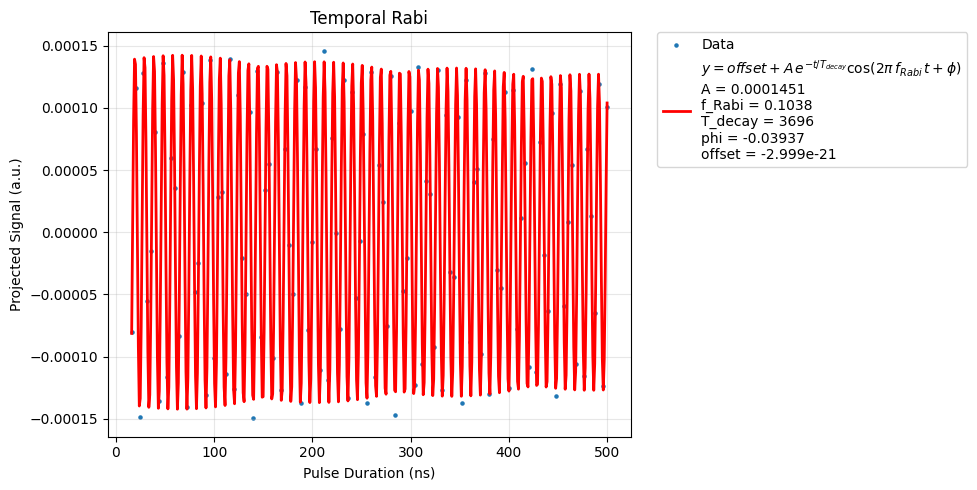

Temporal Rabi pi length estimate: 4.816108 ns
[INFO] 2026-03-22 00:53:30,318 qubox.legacy.analysis.cQED_attributes: Element bindings: readout='resonator' @ 8.7500 GHz, qubit='transmon' @ 6.1500 GHz, storage='storage' @ 5.3500 GHz
Temporal Rabi pi-length calibration for const patch preview (2 updates):
  1. SetCalibration: {'path': 'pulse_calibrations.const.pi_length', 'value': 4.816108187604002}
  2. TriggerPulseRecompile: {'include_volatile': True}
Patch not applied. Set the APPLY_* choice in the settings cell to commit the calibration.


In [ ]:
temporal_rabi = TemporalRabi(session)
temporal_rabi_result = temporal_rabi.run(
    pulse=TEMPORAL_RABI_PULSE,
    pulse_len_begin=TEMPORAL_RABI_LEN_BEGIN,
    pulse_len_end=TEMPORAL_RABI_LEN_END,
    dt=TEMPORAL_RABI_DT,
    n_avg=TEMPORAL_RABI_N_AVG,
    qb_therm_clks=TEMPORAL_RABI_QB_THERM_CLKS,
)
temporal_rabi_analysis = temporal_rabi.analyze(temporal_rabi_result, update_calibration=False)
temporal_rabi.plot(temporal_rabi_analysis)

pi_length_ns = float(temporal_rabi_analysis.metrics.get("pi_length", np.nan))
print(f"Temporal Rabi pi length estimate: {pi_length_ns:.6f} ns")

temporal_patch = None
temporal_patch_preview = None
temporal_apply_result = None
if np.isfinite(pi_length_ns):
    temporal_patch, temporal_patch_preview, temporal_apply_result = preview_or_apply_patch_ops(
        session,
        reason=f"Temporal Rabi pi-length calibration for {TEMPORAL_RABI_PULSE}",
        proposed_patch_ops=[
            {
                "op": "SetCalibration",
                "payload": {
                    "path": f"pulse_calibrations.{TEMPORAL_RABI_PULSE}.pi_length",
                    "value": pi_length_ns,
                },
            },
            {
                "op": "TriggerPulseRecompile",
                "payload": {"include_volatile": True},
            },
        ],
        apply=APPLY_TEMPORAL_RABI_CALIBRATION,
    )

context_snapshot = getattr(session, "context_snapshot", None)
attr = context_snapshot() if callable(context_snapshot) else getattr(session, "attributes", None)
if attr is None:
    raise RuntimeError("Unable to refresh the cQED attribute snapshot at the end of notebook 05.")

stage_checkpoint_path = save_stage_checkpoint(
    registry_base=REGISTRY_BASE,
    sample_id=SAMPLE_ID,
    cooldown_id=COOLDOWN_ID,
    stage_name="05_qubit_spectroscopy_pulse_calibration",
    status="calibrated" if any(result is not None for result in (qubit_apply_result, power_rabi_apply_result, temporal_apply_result)) else "characterized",
    summary="Ran qubit spectroscopy plus pulse calibrations and committed only the operator-approved updates.",
    consumed_inputs={
        "qubit_spec_window_hz": [QUBIT_SPEC_RF_BEGIN, QUBIT_SPEC_RF_END],
        "qubit_spec_n_avg": QUBIT_SPEC_N_AVG,
        "power_rabi_n_avg": POWER_RABI_N_AVG,
        "temporal_rabi_n_avg": TEMPORAL_RABI_N_AVG,
    },
    persisted_outputs={
        "qubit_frequency_applied": qubit_apply_result is not None,
        "power_rabi_applied": power_rabi_apply_result is not None,
        "temporal_rabi_applied": temporal_apply_result is not None,
        "runtime_qb_fq_hz": float(attr.qb_fq),
    },
    advisory_outputs={
        "selected_qubit_trial": chosen_qubit_spec_trial,
        "fitted_qb_f0_hz": float(qubit_analysis.metrics.get("f0", np.nan)) if qubit_analysis is not None else np.nan,
        "power_rabi_g_pi": float(power_rabi_analysis.metrics.get("g_pi", np.nan)) if power_rabi_analysis is not None else np.nan,
        "temporal_rabi_pi_length_ns": pi_length_ns,
    },
    next_stage="06_coherence_experiments",
    notes=[
        "Primitive pulse seeding is now handled by the shared compat workflow helper.",
        "Notebook 06 may assume the committed pulse and qubit-frequency calibrations only when the matching applied flag is true in this checkpoint.",
    ],
    metrics={
        "qubit": dict(qubit_analysis.metrics) if qubit_analysis is not None else {},
        "power_rabi": dict(power_rabi_analysis.metrics) if power_rabi_analysis is not None else {},
        "temporal_rabi": dict(temporal_rabi_analysis.metrics) if temporal_rabi_analysis is not None else {},
    },
)
print(f"Stage checkpoint saved to: {stage_checkpoint_path}")

## 4. Sweep Parameter vs Measured Response

Keep the analysis literal to the experiment sweep: frequency versus measured response for qubit spectroscopy, gain versus measured response for Power Rabi, and pulse duration versus measured response for Temporal Rabi. The fitted markers stay on top of those traces as reference points, not as a replacement for the raw measured data.

In [ ]:
from qubox_tools.algorithms.transforms import project_complex_to_line_real


def project_signal_i(samples):
    samples = np.asarray(samples)
    if samples.size == 0:
        return np.array([])
    projected, _, _ = project_complex_to_line_real(samples)
    return np.asarray(projected, dtype=float)


has_qubit = "qubit_analysis" in globals()
has_power = "power_rabi_analysis" in globals()
has_temporal = "temporal_rabi_analysis" in globals()

if not any((has_qubit, has_power, has_temporal)):
    print("Run qubit spectroscopy, power Rabi, or temporal Rabi above to populate the sweep-versus-response diagnostics.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.5))
    for ax in axes.ravel():
        ax.set_visible(False)

    if has_qubit:
        qubit_S = np.asarray(qubit_analysis.data.get("S", []))
        qubit_freqs_hz = np.asarray(qubit_analysis.data.get("frequencies", []), dtype=float)
        if qubit_S.size and qubit_freqs_hz.size:
            freq_mhz = qubit_freqs_hz / 1e6
            qubit_magnitude = np.abs(qubit_S)
            qubit_phase = np.unwrap(np.angle(qubit_S))
            fitted_qb_f0_hz = float(qubit_analysis.metrics.get("f0", np.nan))

            ax_mag = axes[0, 0]
            ax_phase = axes[0, 1]
            ax_mag.set_visible(True)
            ax_phase.set_visible(True)

            ax_mag.plot(freq_mhz, qubit_magnitude, marker="o", ms=3, lw=1.25, color="#1f77b4")
            ax_mag.set_title("Qubit Spectroscopy: Frequency vs |Measured Response|")
            ax_mag.set_xlabel("Frequency (MHz)")
            ax_mag.set_ylabel("|S|")
            ax_mag.grid(True, alpha=0.3)

            ax_phase.plot(freq_mhz, qubit_phase, marker="o", ms=3, lw=1.25, color="#ff7f0e")
            ax_phase.set_title("Qubit Spectroscopy: Frequency vs Phase")
            ax_phase.set_xlabel("Frequency (MHz)")
            ax_phase.set_ylabel("Phase (rad)")
            ax_phase.grid(True, alpha=0.3)

            marker_rows = [
                ("Runtime attr.qb_fq", float(attr.qb_fq), "#4c78a8"),
                ("Fitted qb_f0", fitted_qb_f0_hz, "#f58518"),
            ]

            for label, freq_hz, color in marker_rows:
                if np.isfinite(freq_hz):
                    ax_mag.axvline(freq_hz / 1e6, color=color, ls="--", lw=1.2, label=label)
                    ax_phase.axvline(freq_hz / 1e6, color=color, ls="--", lw=1.2)

            ax_mag.legend(loc="best")

    if has_power:
        ax = axes[1, 0]
        ax.set_visible(True)
        power_gains = np.asarray(power_rabi_analysis.data.get("gains", []), dtype=float)
        projected = power_rabi_analysis.data.get("projected_S")
        if projected is None:
            projected = project_signal_i(power_rabi_analysis.data.get("S", []))
        projected = np.asarray(projected, dtype=float)
        if power_gains.size and projected.size:
            g_pi = float(power_rabi_analysis.metrics.get("g_pi", np.nan))
            ax.plot(power_gains, projected, marker="o", ms=3, lw=1.25, color="#7a5195")
            if np.isfinite(g_pi):
                ax.axvline(g_pi, color="crimson", ls="--", lw=1.4, label=f"g_pi = {g_pi:.4f}")
            ax.set_title("Power Rabi: Gain vs Measured Response")
            ax.set_xlabel("Gain")
            ax.set_ylabel("Projected S_I")
            ax.grid(True, alpha=0.3)
            if np.isfinite(g_pi):
                ax.legend(loc="best")

    if has_temporal:
        ax = axes[1, 1]
        ax.set_visible(True)
        durations_ns = np.asarray(temporal_rabi_analysis.data.get("pulse_durations", []), dtype=float)
        projected = temporal_rabi_analysis.data.get("projected_S")
        if projected is None:
            projected = project_signal_i(temporal_rabi_analysis.data.get("S", []))
        projected = np.asarray(projected, dtype=float)
        if durations_ns.size and projected.size:
            pi_length_ns = float(temporal_rabi_analysis.metrics.get("pi_length", np.nan))
            ax.plot(durations_ns, projected, marker="o", ms=3, lw=1.25, color="#ef5675")
            if np.isfinite(pi_length_ns):
                ax.axvline(pi_length_ns, color="crimson", ls="--", lw=1.4, label=f"pi length = {pi_length_ns:.3f} ns")
            ax.set_title("Temporal Rabi: Duration vs Measured Response")
            ax.set_xlabel("Pulse duration (ns)")
            ax.set_ylabel("Projected S_I")
            ax.grid(True, alpha=0.3)
            if np.isfinite(pi_length_ns):
                ax.legend(loc="best")

    plt.tight_layout()
    plt.show()

    if has_qubit:
        fitted_qb_f0_hz = float(qubit_analysis.metrics.get("f0", np.nan))
        print(f"Fitted qubit frequency: {fitted_qb_f0_hz / 1e9:.6f} GHz")
        print(f"Runtime delta: {(fitted_qb_f0_hz - float(attr.qb_fq)) / 1e6:+.3f} MHz")

    if has_power:
        g_pi = float(power_rabi_analysis.metrics.get("g_pi", np.nan))
        if np.isfinite(g_pi):
            suggested_amp = REF_R180_AMPLITUDE * g_pi
            print(f"Suggested ref_r180 amplitude: {suggested_amp:.6f}")

    if has_temporal:
        pi_length_ns = float(temporal_rabi_analysis.metrics.get("pi_length", np.nan))
        if np.isfinite(pi_length_ns):
            print(f"Temporal Rabi pi length estimate: {pi_length_ns:.6f} ns")